In [8]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV

## Regression Tree Split Intuition

A regression tree picks splits by testing every possible threshold along a feature's
range. For each candidate threshold, it splits the data into two groups, predicts the
**mean** of each group, and measures the squared error between each point and its
group's mean.

The threshold that gives the **lowest combined squared error** across both groups
wins that's where the split happens.

Intuition: a good split creates two groups that are each internally consistent
(low spread around their own mean). A bad split leaves at least one group scattered,
which means the mean is a poor predictor for those points showing up as high error.

Same idea repeats recursively on each resulting group until a stopping rule
(`max_depth`, `min_samples_leaf`, etc.) kicks in. At each leaf, the prediction is just
the mean of the training points that landed there.

**One-line summary:** classification trees split to reduce *impurity*; regression
trees split to reduce *variance/squared error* same search mechanism, different
error metric.

In [3]:
rng = np.random.RandomState(73)
X = np.sort(rng.uniform(0, 10, 300)).reshape(-1, 1)
y = np.sin(X).ravel() + rng.normal(0, 0.3, X.shape[0])

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=73
)

In [6]:
reg = DecisionTreeRegressor(random_state=73)

reg.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",73
,"max_l

In [7]:
r2_score(y_test, reg.predict(X_test))

0.6729790467623156

# Now Let's do tuning

In [10]:
param_grid = {
    'criterion' : ['squared_error', 'friedman_mse', 'absolute_error'],
    'max_depth': [2, 3, 5, 10, None],
    'min_samples_split': [2, 10, 20, 50],
    'min_samples_leaf': [1, 5, 10, 25],
    'max_leaf_nodes': [None, 10, 25, 50],
    'min_impurity_decrease': [0.0, 0.005, 0.01],
}

grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV MSE:", -grid_search.best_score_)

best_reg = grid_search.best_estimator_
train_mse = mean_squared_error(y_train, best_reg.predict(X_train))
test_mse = mean_squared_error(y_test, best_reg.predict(X_test))
test_r2 = r2_score(y_test, best_reg.predict(X_test))

print(f"\nTrain MSE: {train_mse:.3f}")
print(f"Test MSE:  {test_mse:.3f}")
print(f"Test R²:   {test_r2:.3f}")

Fitting 5 folds for each of 2880 candidates, totalling 14400 fits
Best params: {'criterion': 'squared_error', 'max_depth': 10, 'max_leaf_nodes': 25, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV MSE: 0.091979870570521

Train MSE: 0.054
Test MSE:  0.134
Test R²:   0.712


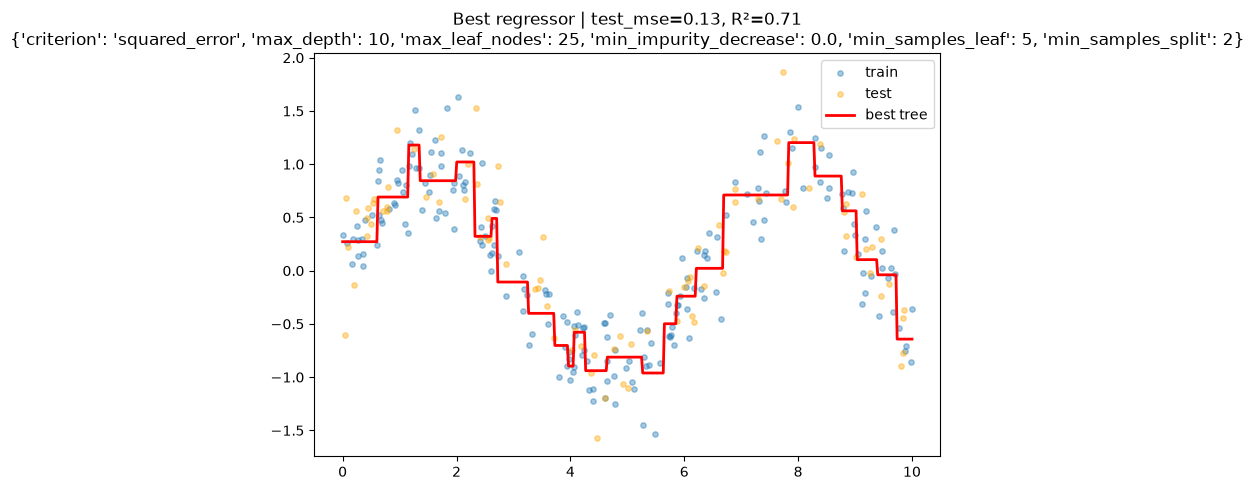

In [11]:
import matplotlib.pyplot as plt

X_plot = np.linspace(0, 10, 500).reshape(-1, 1)

plt.figure(figsize=(7,5))
plt.scatter(X_train, y_train, s=15, alpha=0.4, label='train')
plt.scatter(X_test, y_test, s=15, alpha=0.4, color='orange', label='test')
plt.plot(X_plot, best_reg.predict(X_plot), color='red', linewidth=2, label='best tree')
plt.title(f"Best regressor | test_mse={test_mse:.2f}, R²={test_r2:.2f}\n{grid_search.best_params_}")
plt.legend()
plt.tight_layout()
plt.show()